## 0. How to Run This Notebook on Kaggle
1. **Create the notebook**: Kaggle → *Create* → *New Notebook*, then paste/upload this file.
2. **Settings (right panel)**: Accelerator = **GPU T4 x2** (or P100); Internet = **On**
   (required to `pip install ultralytics` and download the pretrained `yolo26s.pt`);
   Environment = latest.
3. **Attach Notebook 1's output**: *Add Input* → *Your Work* → select the committed
   **Notebook 1** → add its **Output**. The folder `visiodect_yolo/` must appear under
   `/kaggle/input/<notebook-1-slug>/`. (Do **not** attach the raw VisioDECT dataset — this
   notebook trains only on the leakage-checked splits.)
4. *(Optional, for the comparison table)*: also attach the outputs of Notebooks 2/3/5 once
   they exist — their `model_comparison/*.json` files are picked up automatically.
5. Fill in the **group fields** in the title and CONFIG cells.
6. **Run all**. Watch the Section 4 dry run: it extrapolates the full 50-epoch wall time —
   proceed only if the estimate is under ~7 h (leaving ≥1 h for evaluation and saving).
   If it is over budget, lower `BATCH` first; keep `EPOCHS ≥ 50` (assignment minimum).
7. If the session dies mid-training, reopen, set `RESUME = True` in CONFIG, and rerun —
   training continues from `last.pt`.
8. **Commit**: *Save Version* → *Save & Run All*. After it finishes, set visibility to
   **Public** and test the link in an incognito window.

## 1. CONFIG
All parameters are declared here and each is justifiable in the viva. Values marked *(NB1)*
come directly from Notebook 1's measured EDA (`eda_summary.json`), not assumptions.

In [ ]:
# =============================== CONFIG ===============================

# ---- model choice ------------------------------------------------------
VARIANT      = "s"            # YOLOv26 size: n / s / m / l / x  (single switch;
                              # every run/checkpoint name below derives from it)
MODEL_NAME   = f"yolo26{VARIANT}.pt"
# Justification (NB1 + measured dry run): 14,422 training images place us in the
# assignment's 8k-20k band ("m or l"), BUT the mandated 1-epoch dry run measured
# YOLOv26-m at 12.8 min/epoch on a single Kaggle T4 -> 638 min (10.6 h) for 50
# epochs, exceeding the ~9 h session limit. Per assignment §10 (document adapted
# approaches; never deviate silently) the size is stepped down to s: boxes are
# medium-dominated (81.8% in 32^2-96^2) single-object scenes, so s retains
# adequate capacity, and s's ~3x lower GFLOPs (m printed 67.9) brings 50 epochs
# inside budget. The dry run below re-verifies the estimate for s before the
# full run. If even s is over budget: raise WORKERS, then consider GPU T4 x2,
# then (documented) drop to n.
RESUME       = False          # set True to continue a timed-out run from last.pt

# ---- training ----------------------------------------------------------
EPOCHS        = 50            # assignment minimum for YOLO
PATIENCE      = 25            # early stopping on mAP50-95 plateau (assignment: 20-30)
IMGSZ         = 640           # (NB1) medium-dominant boxes -> 640 adequate; 1280 only
                              # if small-object recall stalls (9.0% small share)
BATCH         = 16            # assignment-recommended safe value for T4 @ 640
WORKERS       = 4             # dry run showed only 2 dataloader workers; the
                              # 2400x1080 JPEGs make loading a real bottleneck
OPTIMIZER     = "auto"        # ultralytics picks SGD/AdamW + LR from dataset size
LR0           = 0.01          # initial LR if optimizer resolves to SGD (declared for viva)
COS_LR        = False         # default one-cycle-ish linear decay
WARMUP_EPOCHS = 3             # assignment guidance: 3-5 to stabilise early gradients

# ---- augmentation (mirrors Notebook 1 EDA justifications) ---------------
CLOSE_MOSAIC  = 10    # disable mosaic for final 10 epochs -> better box precision
FLIPLR        = 0.5   # drones are left-right symmetric (NB1 §6)
FLIPUD        = 0.0   # vertical flip excluded: sky/horizon orientation is semantic
DEGREES       = 0.0   # horizon must stay level; affine jitter already in scale
HSV_H, HSV_S, HSV_V = 0.015, 0.7, 0.4   # photometric: NB1 measured a 17-grey-level
                                        # brightness gap across sunny/cloudy/evening
MIXUP         = 0.0   # off: exactly one object/image, classes balanced (1.08x) --
COPY_PASTE    = 0.0   # assignment enables these only for >5 imbalanced classes

# ---- inference / evaluation ---------------------------------------------
CONF_EVAL     = 0.25  # assignment default for evaluation
IOU_NMS       = 0.7   # sparse single-drone scenes -> no duplicate-suppression pressure
CONF_SWEEP    = [0.25, 0.40, 0.50]   # for the precision/recall trade-off analysis

# ---- paths ---------------------------------------------------------------
DATASET_DIR_MANUAL = None     # e.g. Path("/kaggle/input/<nb1-slug>/visiodect_yolo")
WORK_ROOT   = "/kaggle/working"
RUN_PROJECT = f"{WORK_ROOT}/runs_yolov26"
RUN_NAME    = f"yolov26{VARIANT}_visiodect"
DRY_NAME    = f"yolov26{VARIANT}_dryrun"

# ---- clearly named artifacts for cross-model comparison (all NBs use this contract)
CKPT_PATH        = f"{WORK_ROOT}/checkpoints/yolov26{VARIANT}_best.pt"
COMPARISON_JSON  = f"{WORK_ROOT}/model_comparison/yolov26.json"
METRICS_CSV      = f"{WORK_ROOT}/yolov26_test_metrics.csv"
PER_CLASS_CSV    = f"{WORK_ROOT}/yolov26_per_class_metrics.csv"
ERROR_CSV        = f"{WORK_ROOT}/yolov26_error_analysis.csv"
CURVES_PNG       = f"{WORK_ROOT}/yolov26_training_curves.png"

SEED = 42
print(f"CONFIG | {MODEL_NAME} | epochs>={EPOCHS} | imgsz={IMGSZ} | batch={BATCH} "
      f"| checkpoint -> {CKPT_PATH}")


CONFIG | yolo26s.pt | epochs>=50 | imgsz=640 | batch=16 | checkpoint -> /kaggle/working/checkpoints/yolov26s_best.pt


## 2. Environment Setup

In [2]:
!pip install -q -U ultralytics

import os, json, math, time, random, shutil
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

import torch
from ultralytics import YOLO
import ultralytics

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 0 if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.dpi"] = 110

print("ultralytics:", ultralytics.__version__, "| torch:", torch.__version__,
      "| CUDA:", torch.cuda.is_available(),
      "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "-")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.87 | torch: 2.10.0+cu128 | CUDA: True | GPU: Tesla T4


## 3. Locate Notebook 1's Splits & Rebuild `data.yaml`
Notebook 1's `data.yaml` hard-codes `/kaggle/working/...`, which becomes a **read-only
`/kaggle/input/...` path** once attached as an input — so the yaml is regenerated here
against the discovered location (same practice as the course demo). The split is then
verified against Notebook 1's committed counts before any training.

In [3]:
def find_splits_root():
    if DATASET_DIR_MANUAL is not None:
        p = Path(DATASET_DIR_MANUAL)
        if (p / "train" / "images").exists():
            return p
        raise FileNotFoundError(f"Manual path is not a YOLO root: {p}")
    base = Path("/kaggle/input")
    stack, depth = [(base, 0)], 4
    while stack:
        d, dep = stack.pop()
        if d.name == "visiodect_yolo" and (d / "train" / "images").exists():
            return d
        if dep < depth:
            try:
                stack += [(c, dep + 1) for c in d.iterdir() if c.is_dir()]
            except (PermissionError, OSError):
                pass
    raise FileNotFoundError(
        "visiodect_yolo/ not found under /kaggle/input. Attach Notebook 1's OUTPUT "
        "(Add Input -> Your Work -> Notebook 1) or set DATASET_DIR_MANUAL.")

DATASET_ROOT = find_splits_root()
print("Splits root:", DATASET_ROOT)

# class names from Notebook 1's yaml (source of truth for indices)
import yaml as _yaml
nb1_yaml = _yaml.safe_load((DATASET_ROOT / "data.yaml").read_text())
CLASS_NAMES = list(nb1_yaml["names"])
assert len(CLASS_NAMES) == int(nb1_yaml["nc"]) == 6, (CLASS_NAMES, nb1_yaml.get("nc"))
print("Classes:", CLASS_NAMES)

DATA_YAML = Path(WORK_ROOT) / "data.yaml"
DATA_YAML.write_text(
    f"path: {DATASET_ROOT}\ntrain: train/images\nval: val/images\n"
    f"test: test/images\nnc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")
print("\nRegenerated", DATA_YAML, ":\n" + DATA_YAML.read_text())

# NB1's measured EDA, if shipped alongside (used for viva-ready printouts)
eda_path = DATASET_ROOT.parent / "eda_summary.json"
EDA = json.loads(eda_path.read_text()) if eda_path.exists() else {}
if EDA:
    print("NB1 eda_summary.json loaded | per-split counts:", EDA.get("per_split_counts"))


Splits root: /kaggle/input/notebooks/ahnafahmed11/cse445notebook1-datasetexploration-preprocessing/visiodect_yolo
Classes: ['Anafi', 'DJI_FPV', 'DJI_Phantom', 'EFT_E410S', 'Mavic_Air', 'Mavic_Enterprise']

Regenerated /kaggle/working/data.yaml :
path: /kaggle/input/notebooks/ahnafahmed11/cse445notebook1-datasetexploration-preprocessing/visiodect_yolo
train: train/images
val: val/images
test: test/images
nc: 6
names: ['Anafi', 'DJI_FPV', 'DJI_Phantom', 'EFT_E410S', 'Mavic_Air', 'Mavic_Enterprise']

NB1 eda_summary.json loaded | per-split counts: {'train': 14422, 'test': 3091, 'val': 3090}


In [4]:
# ---- split verification against Notebook 1 ---------------------------------
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
split_imgs = {}
for s in ["train", "val", "test"]:
    imgs = sorted(p for p in (DATASET_ROOT / s / "images").iterdir()
                  if p.suffix.lower() in IMG_EXTS)
    lbls = list((DATASET_ROOT / s / "labels").glob("*.txt"))
    split_imgs[s] = imgs
    print(f"{s:<5}: {len(imgs):,} images | {len(lbls):,} labels")
    assert len(imgs) == len(lbls), f"image/label count mismatch in {s}"

if EDA.get("per_split_counts"):
    for s in ["train", "val", "test"]:
        assert len(split_imgs[s]) == EDA["per_split_counts"][s], \
            f"{s} count differs from Notebook 1 commit!"
    print("✔ Split counts match Notebook 1's committed eda_summary.json")

# exported filenames encode class & scenario: "<Class>_<scenario>_<orig>"
SCENARIOS = ["cloudy", "evening", "sunny"]
def parse_stem(stem):
    for cname in sorted(CLASS_NAMES, key=len, reverse=True):
        if stem.startswith(cname + "_"):
            rest = stem[len(cname) + 1:]
            scen = rest.split("_")[0]
            return cname, (scen if scen in SCENARIOS else "unknown")
    return "unknown", "unknown"

meta = pd.DataFrame([{"split": s, "image": str(p), "stem": p.stem,
                      **dict(zip(["class_name", "scenario"], parse_stem(p.stem)))}
                     for s in split_imgs for p in split_imgs[s]])
display(meta.groupby(["split", "class_name"]).size().unstack(fill_value=0))
assert (meta.class_name != "unknown").all() and (meta.scenario != "unknown").all()
print("✔ class & scenario parsed from every filename (enables per-scenario error analysis)")


train: 14,422 images | 14,422 labels
val  : 3,090 images | 3,090 labels
test : 3,091 images | 3,091 labels
✔ Split counts match Notebook 1's committed eda_summary.json


class_name,Anafi,DJI_FPV,DJI_Phantom,EFT_E410S,Mavic_Air,Mavic_Enterprise
split,,,,,,
test,506,516,495,533,529,512
train,2362,2407,2310,2486,2464,2393
val,507,516,495,533,526,513


✔ class & scenario parsed from every filename (enables per-scenario error analysis)


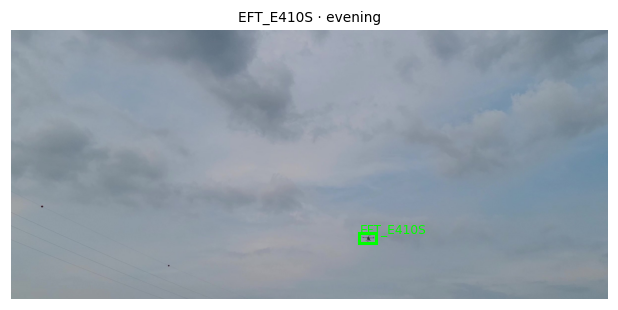

Label file: EFT_E410S_evening_EFT E410S_Evening (491).txt | class index maps to: EFT_E410S


In [5]:
# ---- sanity visual: one labelled train image --------------------------------
r = meta[meta.split == "train"].sample(1, random_state=SEED).iloc[0]
im = np.array(Image.open(r.image).convert("RGB")); H, W = im.shape[:2]
fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(im); ax.set_axis_off(); ax.set_title(f"{r.class_name} · {r.scenario}", fontsize=9)
lbl = Path(r.image.replace("/images/", "/labels/")).with_suffix(".txt")
for ln in lbl.read_text().splitlines():
    t = ln.split()
    if len(t) == 5:
        cid, cx, cy, w, h = int(t[0]), *map(float, t[1:])
        ax.add_patch(mpatches.Rectangle(((cx-w/2)*W, (cy-h/2)*H), w*W, h*H,
                                        fill=False, edgecolor="lime", lw=2))
        ax.text((cx-w/2)*W, (cy-h/2)*H - 4, CLASS_NAMES[cid], color="lime", fontsize=8)
plt.show()
print("Label file:", lbl.name, "| class index maps to:", CLASS_NAMES[cid])


## 4. 1-Epoch Dry Run — Pipeline Check & Time Budget
Assignment requirement: verify the pipeline end-to-end and extrapolate whether
`EPOCHS × per-epoch time` fits Kaggle's ~9 h session (target ≤ 7 h to leave a buffer for
evaluation, error analysis and saving).

In [6]:
try:
    dry_model = YOLO(MODEL_NAME)
    print("Loaded pretrained:", MODEL_NAME)
except Exception as e:
    raise RuntimeError(
        f"Could not load {MODEL_NAME}. Ensure Internet is ON in Kaggle settings, or "
        f"upload the weight file and point MODEL_NAME at it.\nOriginal error: {e}")

t0 = time.time()
dry_model.train(data=str(DATA_YAML), epochs=1, imgsz=IMGSZ, batch=BATCH, device=DEVICE,
                workers=WORKERS,
                project=RUN_PROJECT, name=DRY_NAME, exist_ok=True,
                optimizer=OPTIMIZER, lr0=LR0, cos_lr=COS_LR, warmup_epochs=WARMUP_EPOCHS,
                close_mosaic=0, fliplr=FLIPLR, flipud=FLIPUD, degrees=DEGREES,
                hsv_h=HSV_H, hsv_s=HSV_S, hsv_v=HSV_V, mixup=MIXUP, copy_paste=COPY_PASTE,
                plots=False, verbose=False)
dry_minutes = (time.time() - t0) / 60
est_total = dry_minutes * EPOCHS
print(f"\nDry-run epoch: {dry_minutes:.1f} min -> {EPOCHS}-epoch estimate: "
      f"{est_total:.0f} min ({est_total/60:.1f} h)")
print("Assignment table for m @ >5k images: 160-280 min — estimate should be in range.")
if est_total > 7 * 60:
    print("⚠ OVER BUDGET: lower BATCH (or, with justification, model size) before "
          "the full run.")
else:
    print("✔ Fits the session budget with buffer for evaluation.")
del dry_model; torch.cuda.empty_cache()


Loaded pretrained: yolo26s.pt
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov26s_dryrun, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

## 5. Full Training — 
Fresh training from the pretrained checkpoint (the dry run is discarded so its epoch does
not contaminate the schedule). `close_mosaic=10` disables mosaic for the last 10 epochs per
the assignment guidance. If `RESUME = True`, training instead continues from `last.pt`.

In [7]:
RUN_DIR = Path(RUN_PROJECT) / RUN_NAME
if RESUME and (RUN_DIR / "weights" / "last.pt").exists():
    model = YOLO(str(RUN_DIR / "weights" / "last.pt"))
    print("Resuming from", RUN_DIR / "weights" / "last.pt")
    train_kwargs = dict(resume=True)
else:
    model = YOLO(MODEL_NAME)
    train_kwargs = dict(
        data=str(DATA_YAML), epochs=EPOCHS, patience=PATIENCE, imgsz=IMGSZ,
        batch=BATCH, workers=WORKERS, device=DEVICE, project=RUN_PROJECT, name=RUN_NAME, exist_ok=True,
        optimizer=OPTIMIZER, lr0=LR0, cos_lr=COS_LR, warmup_epochs=WARMUP_EPOCHS,
        close_mosaic=CLOSE_MOSAIC, fliplr=FLIPLR, flipud=FLIPUD, degrees=DEGREES,
        hsv_h=HSV_H, hsv_s=HSV_S, hsv_v=HSV_V, mixup=MIXUP, copy_paste=COPY_PASTE,
        seed=SEED, plots=True, verbose=True)

t0 = time.time()
model.train(**train_kwargs)
TRAIN_MINUTES = (time.time() - t0) / 60
BEST_WEIGHT = RUN_DIR / "weights" / "best.pt"
LAST_WEIGHT = RUN_DIR / "weights" / "last.pt"
print(f"\nTraining wall time: {TRAIN_MINUTES:.1f} min")
print("best.pt exists:", BEST_WEIGHT.exists(), "| last.pt exists:", LAST_WEIGHT.exists())
torch.cuda.empty_cache()


Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov26s_visiodect, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

### 5.1 Training Curves — losses, mAP and learning rate
Read from ultralytics' `results.csv` so the curves shown are exactly what was logged.

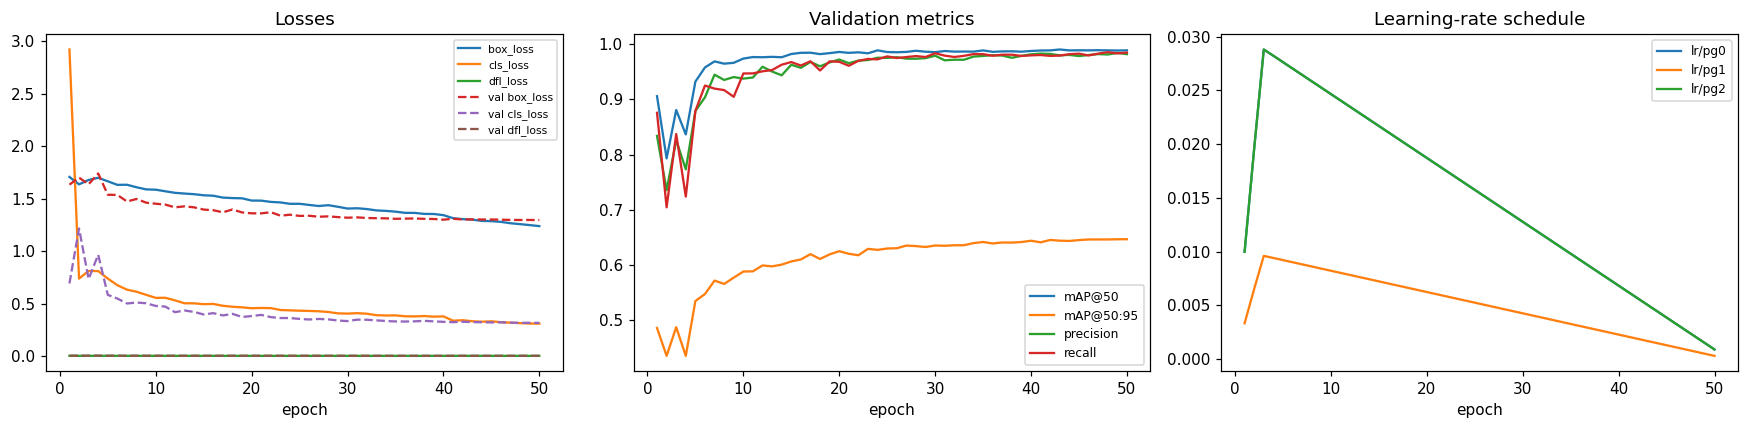

Best val mAP50-95 at epoch 50 of 50 run (early stopping patience=25).
Convergence note for the viva: describe whether losses were still falling at the end (train longer) or plateaued/diverging from val (stop / regularise).


In [8]:
res = pd.read_csv(RUN_DIR / "results.csv")
res.columns = [c.strip() for c in res.columns]
ep = res["epoch"]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for k in ["train/box_loss", "train/cls_loss", "train/dfl_loss"]:
    if k in res: ax[0].plot(ep, res[k], label=k.split("/")[1])
for k in ["val/box_loss", "val/cls_loss", "val/dfl_loss"]:
    if k in res: ax[0].plot(ep, res[k], "--", label="val " + k.split("/")[1])
ax[0].set_title("Losses"); ax[0].set_xlabel("epoch"); ax[0].legend(fontsize=7)

for k, lab in [("metrics/mAP50(B)", "mAP@50"), ("metrics/mAP50-95(B)", "mAP@50:95"),
               ("metrics/precision(B)", "precision"), ("metrics/recall(B)", "recall")]:
    if k in res: ax[1].plot(ep, res[k], label=lab)
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=8)

for k in ["lr/pg0", "lr/pg1", "lr/pg2"]:
    if k in res: ax[2].plot(ep, res[k], label=k)
ax[2].set_title("Learning-rate schedule"); ax[2].set_xlabel("epoch"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(CURVES_PNG, dpi=150, bbox_inches="tight"); plt.show()

best_ep = int(res.loc[res["metrics/mAP50-95(B)"].idxmax(), "epoch"]) \
          if "metrics/mAP50-95(B)" in res else None
print(f"Best val mAP50-95 at epoch {best_ep} of {int(ep.max())} run "
      f"(early stopping patience={PATIENCE}).")
print("Convergence note for the viva: describe whether losses were still falling at the "
      "end (train longer) or plateaued/diverging from val (stop / regularise).")


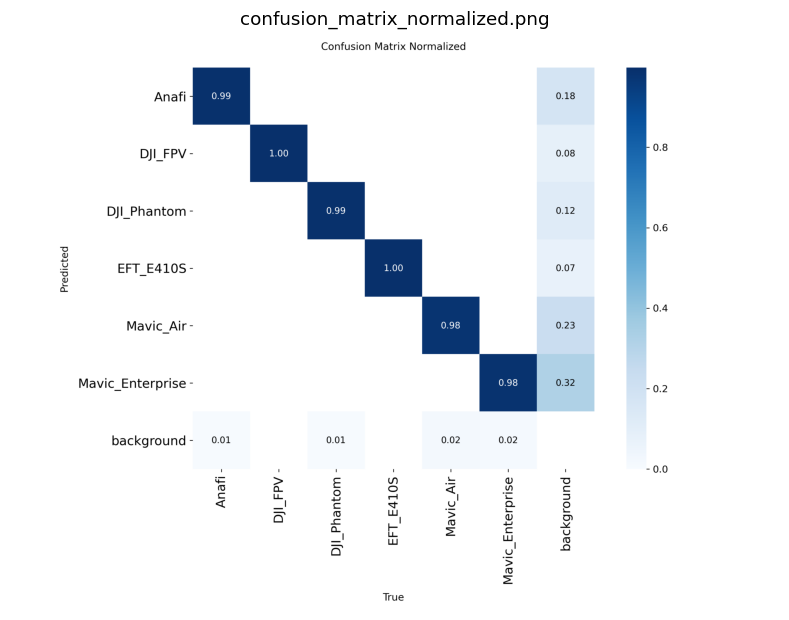

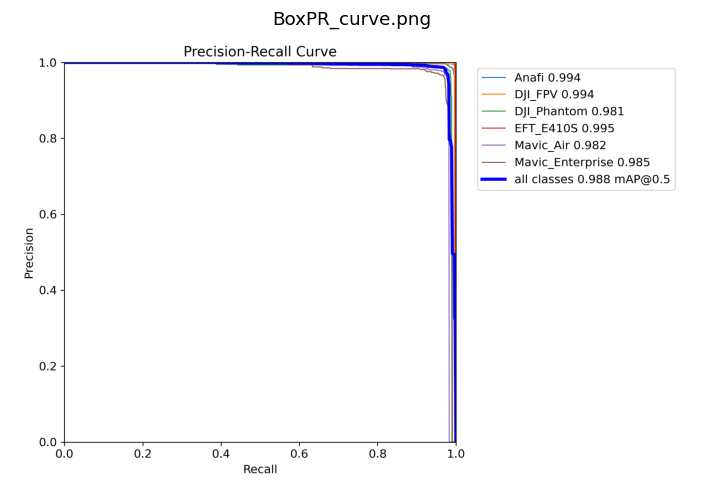

In [9]:
# ---- ultralytics diagnostic plots (confusion matrix, PR curve) --------------
def show_png(path, figsize=(9, 7)):
    p = Path(path)
    if p.exists():
        plt.figure(figsize=figsize); plt.imshow(plt.imread(p)); plt.axis("off")
        plt.title(p.name); plt.show()
    else:
        print("not found:", p)

show_png(RUN_DIR / "confusion_matrix_normalized.png")
for cand in ["PR_curve.png", "BoxPR_curve.png"]:
    if (RUN_DIR / cand).exists():
        show_png(RUN_DIR / cand, figsize=(8, 6)); break
else:
    print("PR curve image not found in run dir (name varies by ultralytics version)")


## 6. Test-Split Evaluation — 
Metrics are computed on the **held-out test split only** (3,091 images the model has never
seen), using `best.pt`. FPS is measured on the same GPU, single-image latency, after warm-up.

In [10]:
eval_model = YOLO(str(BEST_WEIGHT if BEST_WEIGHT.exists() else LAST_WEIGHT))
mtr = eval_model.val(data=str(DATA_YAML), split="test", imgsz=IMGSZ, batch=BATCH,
                     conf=0.001, iou=IOU_NMS, device=DEVICE, plots=True, save_json=True,
                     project=f"{WORK_ROOT}/evaluation", name="yolov26_test", exist_ok=True)

P, R = float(mtr.box.mp), float(mtr.box.mr)
F1 = 2 * P * R / (P + R + 1e-9)
summary = {"model": "YOLOv26", "variant": VARIANT, "epochs_run": int(ep.max()),
           "imgsz": IMGSZ, "batch": BATCH,
           "precision": round(P, 4), "recall": round(R, 4), "f1": round(F1, 4),
           "mAP50": round(float(mtr.box.map50), 4),
           "mAP50_95": round(float(mtr.box.map), 4)}
display(pd.DataFrame([summary]))

# per-class table (assignment: per-class metrics for multi-class datasets)
rows = []
for k, ci in enumerate(mtr.box.ap_class_index):
    rows.append({"class": CLASS_NAMES[int(ci)],
                 "precision": round(float(mtr.box.p[k]), 4),
                 "recall":    round(float(mtr.box.r[k]), 4),
                 "AP50":      round(float(mtr.box.ap50[k]), 4),
                 "AP50_95":   round(float(mtr.box.ap[k]), 4)})
per_class = pd.DataFrame(rows).sort_values("AP50_95")
display(per_class)
per_class.to_csv(PER_CLASS_CSV, index=False)
print("Weakest class by AP50-95:", per_class.iloc[0]["class"],
      "-> first place to look in Section 7.")


Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26s summary (fused): 122 layers, 9,467,502 parameters, 0 gradients, 20.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.3±0.4 ms, read: 15.3±6.5 MB/s, size: 92.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/notebooks/ahnafahmed11/cse445notebook1-datasetexploration-preprocessing/visiodect_yolo/test/labels... 3091 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3091/3091 189.2it/s 16.3s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/ahnafahmed11/cse445notebook1-datasetexploration-preprocessing/visiodect_yolo/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 194/194 6.6it/s 29.2s
                   all       3091       3092      0.986      0.984       0.99     

,model,variant,epochs_run,imgsz,batch,precision,recall,f1,mAP50,mAP50_95
0,YOLOv26,s,50,640,16,0.9858,0.9835,0.9847,0.9898,0.6489


,class,precision,recall,AP50,AP50_95
5,Mavic_Enterprise,0.9746,0.9744,0.9782,0.5678
2,DJI_Phantom,0.9897,0.9899,0.9942,0.5865
4,Mavic_Air,0.9757,0.9754,0.9823,0.5884
0,Anafi,0.9899,0.9700,0.9942,0.6488
1,DJI_FPV,0.9923,0.9925,0.9950,0.6918
3,EFT_E410S,0.9925,0.9989,0.9950,0.8103


Weakest class by AP50-95: Mavic_Enterprise -> first place to look in Section 7.


In [11]:
# ---- FPS on the same hardware (single-image latency, post-warm-up) ----------
test_paths = [str(p) for p in split_imgs["test"][:110]]
warm, timed = test_paths[:10], test_paths[10:]
for p in warm:                                              # warm-up
    eval_model.predict(p, imgsz=IMGSZ, conf=CONF_EVAL, device=DEVICE, verbose=False)
t0 = time.time()
for p in timed:
    eval_model.predict(p, imgsz=IMGSZ, conf=CONF_EVAL, device=DEVICE, verbose=False)
FPS = len(timed) / (time.time() - t0)
summary["fps_single_image"] = round(FPS, 1)
summary["train_minutes"] = round(TRAIN_MINUTES, 1)
print(f"FPS (batch=1, {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}): "
      f"{FPS:.1f}")

pd.DataFrame([summary]).to_csv(METRICS_CSV, index=False)
print("Saved:", METRICS_CSV)


FPS (batch=1, Tesla T4): 67.9
Saved: /kaggle/working/yolov26_test_metrics.csv


### 6.1 Qualitative Prediction Check 
One test image per scenario pair, with **predictions in red** (label + confidence) and the
**ground truth in green** for reference — a fast visual sanity check that detections look
reasonable before the systematic error analysis of Section 7.

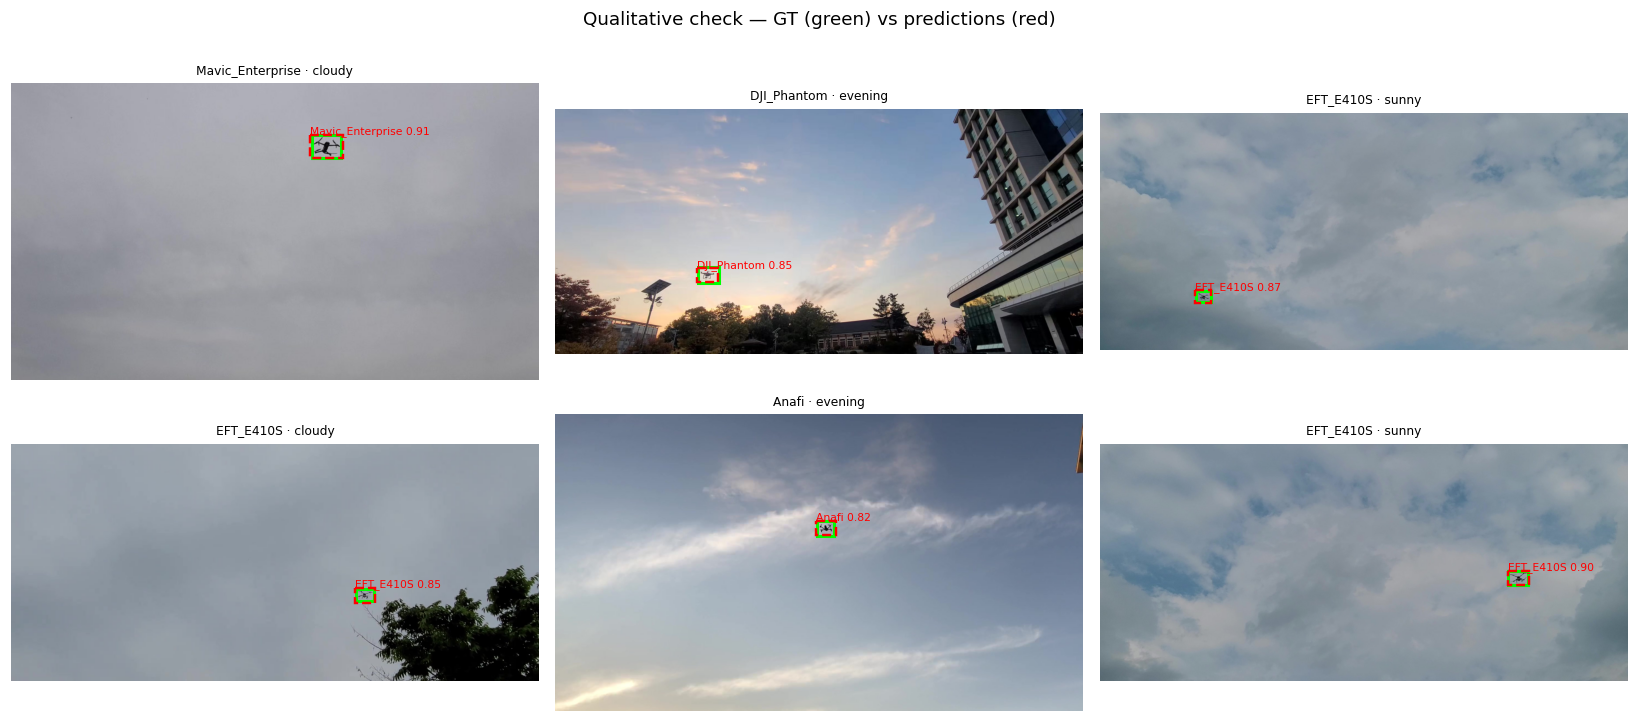

In [12]:
qual = (meta[meta.split == "test"]
        .sample(frac=1, random_state=SEED)     # shuffle, then head-per-group:
        .groupby("scenario").head(2)           # version-proof (groupby.apply drops
        .sort_values("scenario").reset_index(drop=True))  # group cols in pandas>=2.2)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (_, r) in zip(axes.T.ravel(), qual.iterrows()):
    im = np.array(Image.open(r.image).convert("RGB")); H, W = im.shape[:2]
    ax.imshow(im); ax.set_axis_off()
    lbl = Path(r.image.replace("/images/", "/labels/")).with_suffix(".txt")
    for ln in lbl.read_text().splitlines():
        t = ln.split()
        if len(t) == 5:
            _, cx, cy, w, h = map(float, t)
            ax.add_patch(mpatches.Rectangle(((cx-w/2)*W, (cy-h/2)*H), w*W, h*H,
                                            fill=False, edgecolor="lime", lw=2))
    res_ = eval_model.predict(r.image, imgsz=IMGSZ, conf=CONF_EVAL, iou=IOU_NMS,
                              device=DEVICE, verbose=False)[0]
    if res_.boxes is not None:
        for b, c, s in zip(res_.boxes.xyxy.cpu().numpy(),
                           res_.boxes.cls.cpu().numpy().astype(int),
                           res_.boxes.conf.cpu().numpy()):
            ax.add_patch(mpatches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                            fill=False, edgecolor="red", lw=1.6,
                                            linestyle="--"))
            ax.text(b[0], b[1]-4, f"{CLASS_NAMES[int(c)]} {s:.2f}", color="red", fontsize=7)
    ax.set_title(f"{r.class_name} · {r.scenario}", fontsize=8)
fig.suptitle("Qualitative check — GT (green) vs predictions (red)")
plt.tight_layout(); plt.show()


## 7. Error Analysis — 
Predictions are collected once over the **entire test split** at `conf=0.25` and matched to
ground truth (class-aware greedy IoU ≥ 0.5, as in the course demo). Because Notebook 1's
exported filenames encode class **and scenario**, failures can be sliced by lighting
condition — directly testing Notebook 1's prediction that *evening* is the dominant failure
mode. With exactly one drone per image: an unmatched GT ⇒ **false negative** frame; every
unmatched prediction ⇒ **false positive**.

In [13]:
def iou_xyxy(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / (ua + 1e-9)

def gt_for(img_path):
    lbl = Path(str(img_path).replace("/images/", "/labels/")).with_suffix(".txt")
    with Image.open(img_path) as im:
        W, H = im.size
    out = []
    for ln in lbl.read_text().splitlines():
        t = ln.split()
        if len(t) == 5:
            c, cx, cy, w, h = int(t[0]), *map(float, t[1:])
            out.append({"cls": c, "box": [(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H],
                        "area": w*W*h*H})
    return out, (W, H)

def match(gt, preds, thr=0.50):
    used, tp_pairs = set(), []
    for pi, pr in sorted(enumerate(preds), key=lambda x: -x[1]["score"]):
        best_i, best_g = 0, None
        for gi, g in enumerate(gt):
            if gi in used or g["cls"] != pr["cls"]:
                continue
            i = iou_xyxy(pr["box"], g["box"])
            if i > best_i:
                best_i, best_g = i, gi
        if best_g is not None and best_i >= thr:
            used.add(best_g); tp_pairs.append((best_g, pi, best_i))
    tp = len(tp_pairs)
    return tp, len(preds) - tp, len(gt) - tp, tp_pairs

# ---- single prediction sweep over the full test split (cached for reuse) ----
pred_cache, CHUNK = {}, 32
test_all = [str(p) for p in split_imgs["test"]]
for i in tqdm(range(0, len(test_all), CHUNK), desc="predicting test split"):
    chunk = test_all[i:i+CHUNK]
    results = eval_model.predict(chunk, imgsz=IMGSZ, conf=CONF_EVAL,
                                 iou=IOU_NMS, device=DEVICE, verbose=False)
    # NOTE: results are keyed by the INPUT paths (order-preserving zip) because
    # ultralytics rewrites res.path to image0.jpg... for list sources.
    for src_path, res_ in zip(chunk, results):
        preds = []
        if res_.boxes is not None:
            for b, c, s in zip(res_.boxes.xyxy.cpu().numpy(),
                               res_.boxes.cls.cpu().numpy().astype(int),
                               res_.boxes.conf.cpu().numpy()):
                preds.append({"cls": int(c), "box": b.tolist(), "score": float(s)})
        pred_cache[Path(src_path).name] = preds

rows = []
for img in tqdm(test_all, desc="matching"):
    gt, _ = gt_for(img)
    tp, fp, fn, _ = match(gt, pred_cache[Path(img).name])
    st = Path(img).stem
    cname, scen = parse_stem(st)
    rows.append({"image": img, "class_name": cname, "scenario": scen,
                 "gt": len(gt), "tp": tp, "fp": fp, "fn": fn,
                 "gt_area": gt[0]["area"] if gt else np.nan})
err = pd.DataFrame(rows)
err.to_csv(ERROR_CSV, index=False)
print(f"Test frames: {len(err):,} | FN frames: {(err.fn>0).sum():,} "
      f"({(err.fn>0).mean():.2%}) | FP boxes: {err.fp.sum():,}")


predicting test split:   0%|          | 0/97 [00:00<?, ?it/s]

matching:   0%|          | 0/3091 [00:00<?, ?it/s]

Test frames: 3,091 | FN frames: 61 (1.97%) | FP boxes: 105


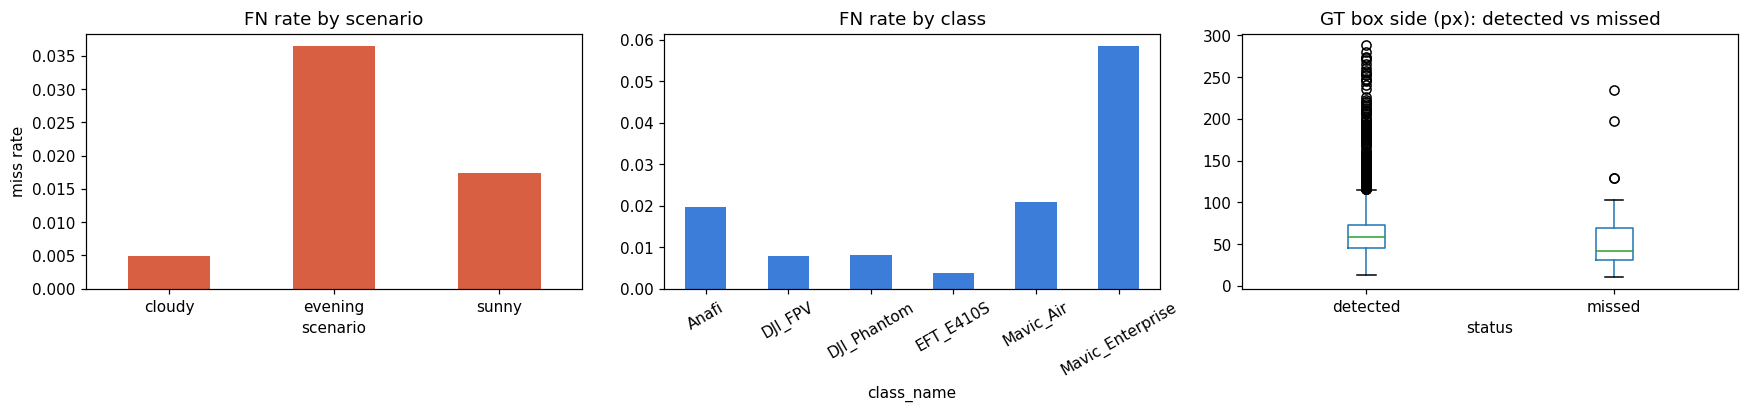

Computed failure-pattern candidate:
  worst scenario : evening (3.65% miss rate)
  worst class    : Mavic_Enterprise (5.86% miss rate)
  size effect    : missed boxes are 17px smaller in median side than detected ones
Use these numbers to write the failure-pattern summary below in your own words.


In [14]:
# ---- failure-pattern breakdown: scenario, class, object size ---------------
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
(err.groupby("scenario").fn.mean()).plot.bar(ax=ax[0], color="#d95f43", rot=0)
ax[0].set_title("FN rate by scenario"); ax[0].set_ylabel("miss rate")
(err.groupby("class_name").fn.mean()).plot.bar(ax=ax[1], color="#3b7dd8", rot=30)
ax[1].set_title("FN rate by class")
err["side"] = np.sqrt(err.gt_area)
err["status"] = np.where(err.fn > 0, "missed", "detected")
if err.status.nunique() > 1:
    err.boxplot(column="side", by="status", ax=ax[2], grid=False)
else:  # degenerate case (all detected or all missed)
    err.side.plot.hist(bins=30, ax=ax[2], color="#8657c2")
plt.suptitle(""); ax[2].set_title("GT box side (px): detected vs missed")
plt.tight_layout(); plt.savefig(f"{WORK_ROOT}/yolov26_failure_breakdown.png",
                                dpi=150, bbox_inches="tight"); plt.show()

fn_scen = err.groupby("scenario").fn.mean().sort_values(ascending=False)
fn_cls  = err.groupby("class_name").fn.mean().sort_values(ascending=False)
side_gap = (err[err.fn>0]["side"].median() - err[err.fn==0]["side"].median())            if err.status.nunique() > 1 else 0.0
print(f"Computed failure-pattern candidate:")
print(f"  worst scenario : {fn_scen.index[0]} ({fn_scen.iloc[0]:.2%} miss rate)")
print(f"  worst class    : {fn_cls.index[0]} ({fn_cls.iloc[0]:.2%} miss rate)")
print(f"  size effect    : missed boxes are {abs(side_gap):.0f}px "
      f"{'smaller' if side_gap<0 else 'larger'} in median side than detected ones")
print("Use these numbers to write the failure-pattern summary below in your own words.")


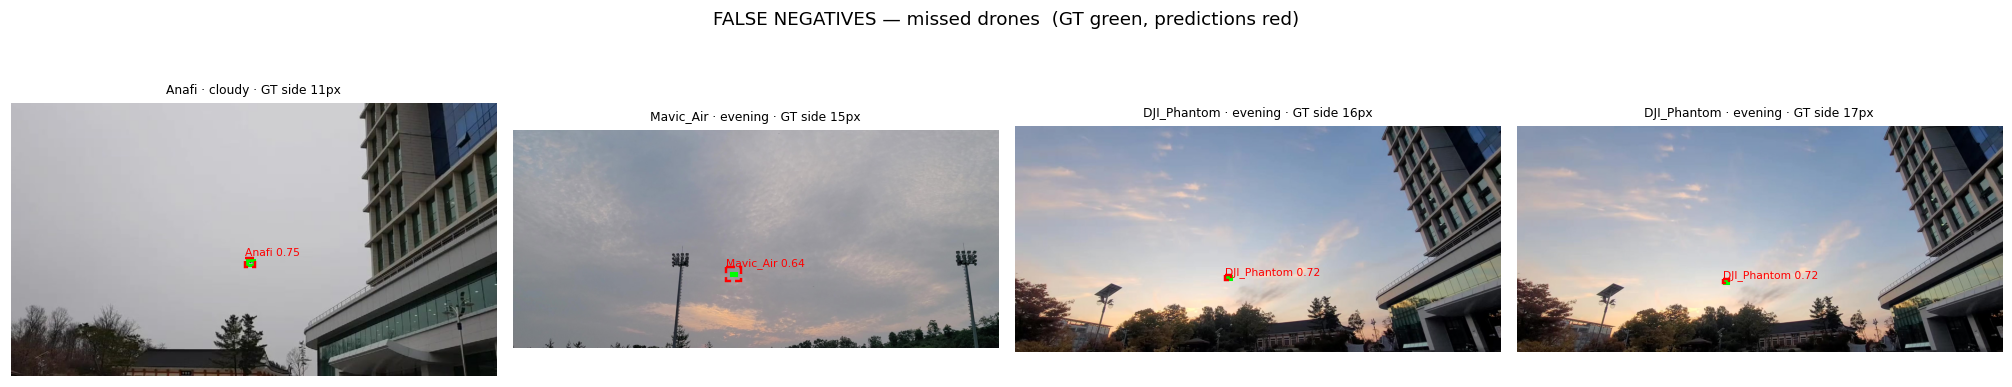

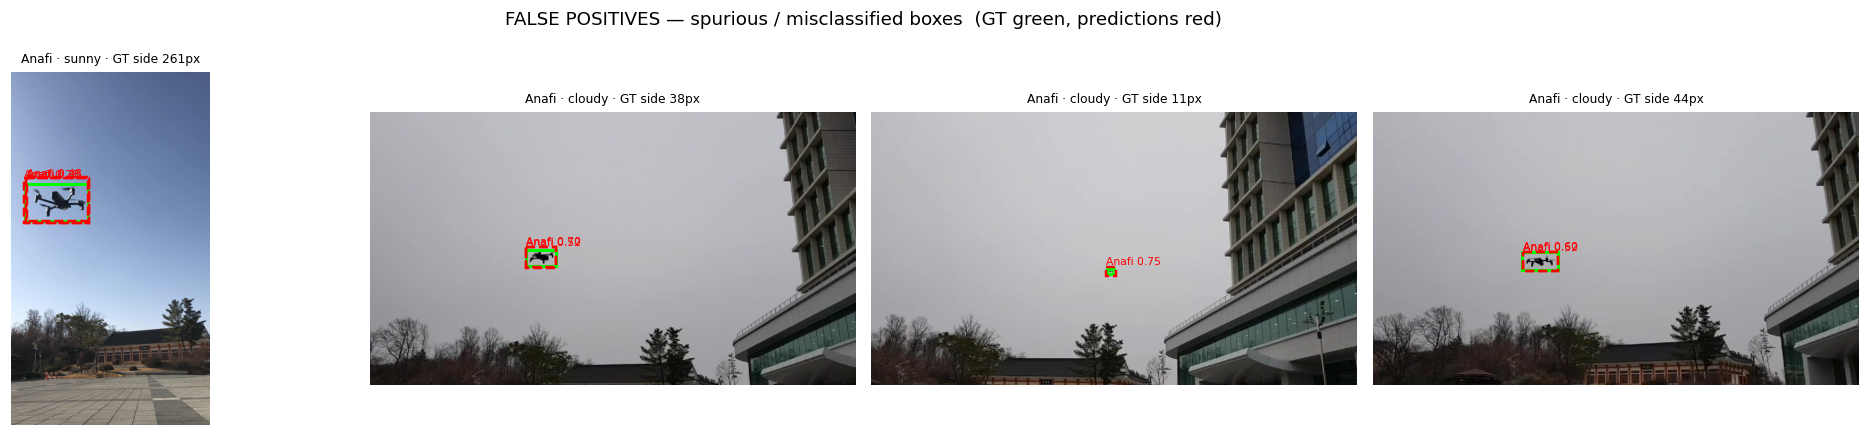

FN pool: 61 frames | FP pool: 104 frames (re-run draw_cases with .iloc slices to inspect more).


In [15]:
# ---- >=3 false negatives with GT overlay (green) + any preds (red) ----------
def draw_cases(frame, title, n=4):
    frame = frame.head(n)
    if frame.empty:
        print(f"{title}: no cases in this pool."); return
    fig, axes = plt.subplots(1, len(frame), figsize=(4.6*len(frame), 4))
    axes = np.atleast_1d(axes)
    for ax, (_, r) in zip(axes, frame.iterrows()):
        im = np.array(Image.open(r.image).convert("RGB"))
        ax.imshow(im); ax.set_axis_off()
        gt, _ = gt_for(r.image)
        for g in gt:
            x1, y1, x2, y2 = g["box"]
            ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                            edgecolor="lime", lw=2))
        for p in pred_cache[Path(r.image).name]:
            x1, y1, x2, y2 = p["box"]
            ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                            edgecolor="red", lw=1.6, linestyle="--"))
            ax.text(x1, y1-4, f"{CLASS_NAMES[p['cls']]} {p['score']:.2f}",
                    color="red", fontsize=7)
        ax.set_title(f"{r.class_name} · {r.scenario} · GT side {r.side:.0f}px", fontsize=8)
    fig.suptitle(title + "  (GT green, predictions red)")
    plt.tight_layout(); plt.show()

fn_cases = err[err.fn > 0].sort_values("side").reset_index(drop=True)   # hardest first
draw_cases(fn_cases, "FALSE NEGATIVES — missed drones")
fp_cases = err[err.fp > 0].sort_values("fp", ascending=False).reset_index(drop=True)
draw_cases(fp_cases, "FALSE POSITIVES — spurious / misclassified boxes")
print(f"FN pool: {len(fn_cases)} frames | FP pool: {len(fp_cases)} frames "
      "(re-run draw_cases with .iloc slices to inspect more).")


### True positives — and why "true negatives" do not exist here
The panels above cover **FN** (missed drones) and **FP** (spurious boxes). Below are **TP**
cases — correct detections with the matched IoU shown.

**True negatives are structurally undefined in object detection**: a TN would be "background
correctly not detected", but an image contains an unbounded number of background regions, so
TN cannot be counted — which is exactly why detection uses precision, recall and mAP (none of
which needs TN) rather than accuracy. On VisioDECT specifically there are also **zero
negative frames**: every test image contains a drone by construction (Notebook 1 §3.5
excluded all unannotated frames), so even a frame-level TN ("empty image, no prediction")
has no members. The closest observable notion is visible in the TP panel itself — the whole
sky and terrain around each green box is background the model correctly leaves un-boxed.

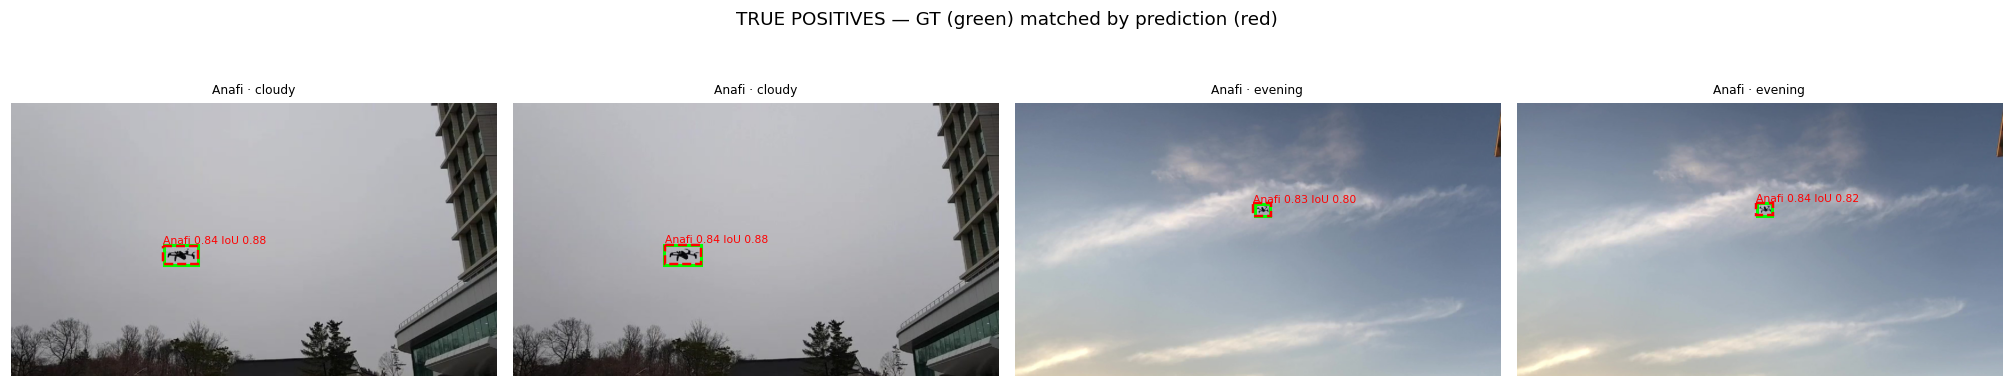

Clean-TP frames in test split: 2,975 of 3,091


In [16]:
# ---- true-positive cases: correct detections with matched IoU ---------------
tp_pool = err[(err.tp > 0) & (err.fp == 0)]
tp_pool = tp_pool.groupby("scenario", group_keys=False).head(2).head(4).reset_index(drop=True)
if tp_pool.empty:
    print("No clean TP frames found (unexpected on a trained model).")
else:
    fig, axes = plt.subplots(1, len(tp_pool), figsize=(4.6*len(tp_pool), 4))
    axes = np.atleast_1d(axes)
    for ax, (_, r) in zip(axes, tp_pool.iterrows()):
        im = np.array(Image.open(r.image).convert("RGB"))
        ax.imshow(im); ax.set_axis_off()
        gt, _ = gt_for(r.image)
        preds = pred_cache[Path(r.image).name]
        _, _, _, pairs = match(gt, preds)
        for g in gt:
            x1, y1, x2, y2 = g["box"]
            ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                            edgecolor="lime", lw=2))
        for gi, pi, i_ in pairs:
            x1, y1, x2, y2 = preds[pi]["box"]
            ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                            edgecolor="red", lw=1.6, linestyle="--"))
            ax.text(x1, y1-4, f"{CLASS_NAMES[preds[pi]['cls']]} "
                              f"{preds[pi]['score']:.2f} IoU {i_:.2f}",
                    color="red", fontsize=7)
        ax.set_title(f"{r.class_name} · {r.scenario}", fontsize=8)
    fig.suptitle("TRUE POSITIVES — GT (green) matched by prediction (red)")
    plt.tight_layout(); plt.show()
print(f"Clean-TP frames in test split: {((err.tp>0)&(err.fp==0)).sum():,} of {len(err):,}")


### 7.1 Written cause analysis 
For **each of ≥3 FN cases**: state the likely cause — e.g. *small apparent size* (check the
px side in the panel title), *low contrast against cloud/sky*, *evening under-exposure*,
*motion blur*, or *out-of-distribution pose* — and one hyperparameter/augmentation change
that could address it. For **each of ≥3 FP cases**: classify as *background object mistaken
for drone* (birds, poles, lens flare), *duplicate box*, or *cross-class confusion* (check the
red label against the folder class; the confusion matrix in §5.1 shows which drone pairs are
confused).

**Failure-pattern summary** (one paragraph, grounded in §7's computed numbers): name the one
dominant failure mode of YOLOv26-m on VisioDECT — the printed worst scenario / worst class /
size-effect line gives the evidence to cite.

### 7.2 Confidence-threshold trade-off (`conf` 0.25 → 0.50)
Recomputed from the cached predictions — no re-inference needed. This answers the standard
viva question on how precision and recall move as the confidence threshold rises.

In [17]:
sweep = []
for cth in CONF_SWEEP:
    TP = FP = FN = 0
    for img in test_all:
        gt, _ = gt_for(img)
        preds = [p for p in pred_cache[Path(img).name] if p["score"] >= cth]
        tp, fp, fn, _ = match(gt, preds)
        TP += tp; FP += fp; FN += fn
    p_ = TP / (TP + FP + 1e-9); r_ = TP / (TP + FN + 1e-9)
    sweep.append({"conf": cth, "TP": TP, "FP": FP, "FN": FN,
                  "precision": round(p_, 4), "recall": round(r_, 4),
                  "f1": round(2*p_*r_/(p_+r_+1e-9), 4)})
sweep_df = pd.DataFrame(sweep)
display(sweep_df)
sweep_df.to_csv(f"{WORK_ROOT}/yolov26_conf_sweep.csv", index=False)
print("Expected pattern: precision rises and recall falls as conf increases — "
      "quantified here at IoU 0.5 matching.")


,conf,TP,FP,FN,precision,recall,f1
0,0.25,3031,105,61,0.9665,0.9803,0.9733
1,0.40,3011,61,81,0.9801,0.9738,0.9770
2,0.50,2988,53,104,0.9826,0.9664,0.9744


Expected pattern: precision rises and recall falls as conf increases — quantified here at IoU 0.5 matching.


### 7.3 Bonus XAI — EigenCAM Attention Heatmaps
*(Beyond the assignment requirements.)* EigenCAM visualises **where the network looks**: it
projects the detection head's input feature maps onto their first principal component —
no gradients or class targets needed, so it works unchanged on YOLOv26's architecture (it is
implemented here from first principles with forward hooks rather than an external library).
The three neck scales (P3/P4/P5) are combined so both small and large drones register.
Reading the panels: on **TP** frames the heat should sit on the drone; on **FN** frames the
heatmap distinguishes *"the backbone never saw it"* (no heat on the drone → a
feature/resolution problem) from *"seen but rejected"* (heat present → a confidence/head
problem) — evidence to cite in the failure-pattern summary.

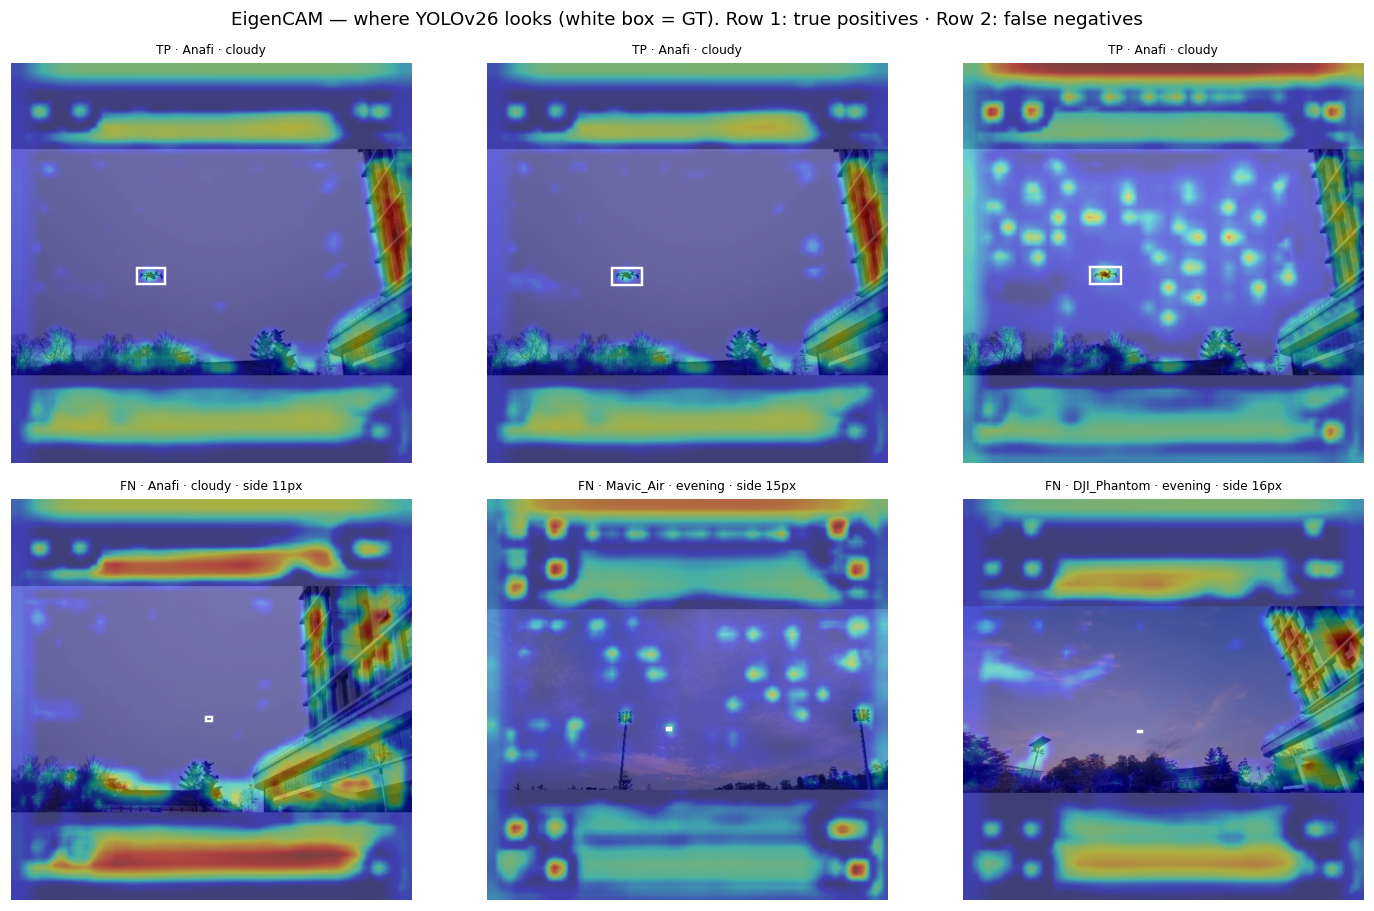

For each FN above, note whether the drone location carries heat (seen-but-rejected) or none (never represented) — and cite it in §7.1.


In [18]:
import torch.nn.functional as Fnn
from ultralytics.data.augment import LetterBox

core = eval_model.model            # underlying DetectionModel
core.eval()
detect_head = core.model[-1]
_feats = {}
def _pre_hook(module, args):
    _feats["p"] = [f.detach().float().cpu() for f in args[0]]
hook = detect_head.register_forward_pre_hook(_pre_hook)
_lb = LetterBox((IMGSZ, IMGSZ))
_dev = next(core.parameters()).device
_dtype = next(core.parameters()).dtype

def eigencam(img_path):
    """Return (letterboxed image, combined EigenCAM heatmap, gt boxes in letterbox px)."""
    im0 = np.array(Image.open(img_path).convert("RGB"))
    H0, W0 = im0.shape[:2]
    lbim = _lb(image=im0)
    t = torch.from_numpy(lbim.copy()).permute(2, 0, 1)[None].to(_dev, _dtype) / 255
    with torch.no_grad():
        core(t)
    cams = []
    for f in _feats["p"]:                       # per neck scale
        C, Hf, Wf = f.shape[1:]
        A = f[0].reshape(C, -1).T               # (HW, C)
        A = A - A.mean(0, keepdim=True)
        Vh = torch.linalg.svd(A, full_matrices=False).Vh
        proj = (A @ Vh[0]).reshape(Hf, Wf)      # 1st principal component projection
        if proj.max() < -proj.min():
            proj = -proj                        # sign so salient regions are positive
        proj = torch.relu(proj)
        cam = Fnn.interpolate(proj[None, None], size=(IMGSZ, IMGSZ),
                              mode="bilinear", align_corners=False)[0, 0]
        cams.append(cam / (cam.max() + 1e-9))
    heat = torch.stack(cams).mean(0).numpy()
    # transform GT boxes into letterbox coordinates for reference outlines
    r_ = min(IMGSZ / W0, IMGSZ / H0)
    dw, dh = (IMGSZ - W0 * r_) / 2, (IMGSZ - H0 * r_) / 2
    gt, _ = gt_for(img_path)
    boxes = [[b*r_ + (dw if k % 2 == 0 else dh) for k, b in enumerate(g["box"])] for g in gt]
    return lbim, heat, boxes

tp_pick = err[(err.tp > 0) & (err.fp == 0)].head(3)
fn_pick = err[err.fn > 0].sort_values("side").head(3)
panels = [("TP", r) for _, r in tp_pick.iterrows()] + \
         [("FN", r) for _, r in fn_pick.iterrows()]
if panels:
    fig, axes = plt.subplots(2, max(len(tp_pick), len(fn_pick), 1),
                             figsize=(4.4*max(len(tp_pick), len(fn_pick), 1), 8.4))
    axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.set_axis_off()
    for col, (tag, r) in enumerate(panels[:len(tp_pick)]):
        lbim, heat, boxes = eigencam(r.image)
        ax = axes[0, col]; ax.imshow(lbim); ax.imshow(heat, cmap="jet", alpha=0.45)
        for x1, y1, x2, y2 in boxes:
            ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                            edgecolor="white", lw=1.6))
        ax.set_title(f"{tag} · {r.class_name} · {r.scenario}", fontsize=8)
    for col, (tag, r) in enumerate(panels[len(tp_pick):]):
        lbim, heat, boxes = eigencam(r.image)
        ax = axes[1, col]; ax.imshow(lbim); ax.imshow(heat, cmap="jet", alpha=0.45)
        for x1, y1, x2, y2 in boxes:
            ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                            edgecolor="white", lw=1.6))
        ax.set_title(f"{tag} · {r.class_name} · {r.scenario} · side {r.side:.0f}px",
                     fontsize=8)
    fig.suptitle("EigenCAM — where YOLOv26 looks (white box = GT). "
                 "Row 1: true positives · Row 2: false negatives")
    plt.tight_layout()
    plt.savefig(f"{WORK_ROOT}/yolov26_eigencam.png", dpi=150, bbox_inches="tight")
    plt.show()
hook.remove()
print("For each FN above, note whether the drone location carries heat "
      "(seen-but-rejected) or none (never represented) — and cite it in §7.1.")


## 8. Save Best Checkpoint & Comparison Artifacts
The assignment requires the best checkpoint at a **clearly named `/kaggle/working/` path,
recorded in the notebook, for cross-model comparison.** All four model notebooks write the
same contract so Notebook comparisons are one `pd.concat` away:

| Artifact | Path |
|---|---|
| **Best checkpoint** | **`/kaggle/working/checkpoints/yolov26<variant>_best.pt`** (variant from CONFIG, e.g. `yolov26s_best.pt`) |
| Comparison record | `/kaggle/working/model_comparison/yolov26.json` |
| Test metrics / per-class / errors / conf sweep | `yolov26_*.csv` in `/kaggle/working/` |
| Training curves | `yolov26_training_curves.png` |

In [19]:
Path(CKPT_PATH).parent.mkdir(parents=True, exist_ok=True)
Path(COMPARISON_JSON).parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(BEST_WEIGHT if BEST_WEIGHT.exists() else LAST_WEIGHT, CKPT_PATH)

summary["best_epoch"] = best_ep
summary["checkpoint"] = CKPT_PATH
summary["fn_rate_by_scenario"] = err.groupby("scenario").fn.mean().round(4).to_dict()
Path(COMPARISON_JSON).write_text(json.dumps(summary, indent=2))

print("BEST CHECKPOINT ->", CKPT_PATH,
      f"({Path(CKPT_PATH).stat().st_size/1e6:.1f} MB)")
print("COMPARISON JSON ->", COMPARISON_JSON)
print(json.dumps(summary, indent=2))


BEST CHECKPOINT -> /kaggle/working/checkpoints/yolov26s_best.pt (20.3 MB)
COMPARISON JSON -> /kaggle/working/model_comparison/yolov26.json
{
  "model": "YOLOv26",
  "variant": "s",
  "epochs_run": 50,
  "imgsz": 640,
  "batch": 16,
  "precision": 0.9858,
  "recall": 0.9835,
  "f1": 0.9847,
  "mAP50": 0.9898,
  "mAP50_95": 0.6489,
  "fps_single_image": 67.9,
  "train_minutes": 322.6,
  "best_epoch": 50,
  "checkpoint": "/kaggle/working/checkpoints/yolov26s_best.pt",
  "fn_rate_by_scenario": {
    "cloudy": 0.0049,
    "evening": 0.0365,
    "sunny": 0.0174
  }
}


### 8.1 Cross-model comparison
Reads every `model_comparison/*.json` visible in this session — the local YOLOv26 record
plus any attached outputs from Notebooks 2, 3 and 5. Until those notebooks exist this table
shows YOLOv26 alone; re-running later with their outputs attached completes it.

In [20]:
records = []
for j in list(Path(WORK_ROOT).glob("model_comparison/*.json")) + \
         list(Path("/kaggle/input").glob("*/model_comparison/*.json")):
    try:
        records.append(json.loads(j.read_text()))
    except Exception:
        pass
comp = pd.DataFrame(records)
cols = [c for c in ["model", "variant", "mAP50", "mAP50_95", "precision", "recall",
                    "f1", "fps_single_image", "train_minutes", "best_epoch"] if c in comp]
display(comp[cols].sort_values("mAP50_95", ascending=False)
        if "mAP50_95" in comp else comp)
print("Deployment lens for the viva: rank by mAP50-95 for accuracy, by FPS for real-time — "
      "state which you would ship and under what latency constraint.")


,model,variant,mAP50,mAP50_95,precision,recall,f1,fps_single_image,train_minutes,best_epoch
0,YOLOv26,s,0.9898,0.6489,0.9858,0.9835,0.9847,67.9,322.6,50


Deployment lens for the viva: rank by mAP50-95 for accuracy, by FPS for real-time — state which you would ship and under what latency constraint.


## 9. Optional — ONNX Export (deployment check demo)
Not required by the assignment tasks, but the demo notebook includes deployment export and
it costs one cell: a portable ONNX copy of the best checkpoint, useful for the FPS/deployment
discussion in the viva.

In [21]:
try:
    onnx_path = Path(eval_model.export(format="onnx", imgsz=IMGSZ, simplify=True))
    dst = Path(WORK_ROOT) / "checkpoints" / f"yolov26{VARIANT}_best.onnx"
    shutil.move(str(onnx_path), dst)
    print(f"ONNX -> {dst} ({dst.stat().st_size/1e6:.1f} MB)")
except Exception as e:
    print("ONNX export skipped (missing onnx deps is fine on Kaggle):", e)


Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs_yolov26/yolov26s_visiodect/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.4 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 259ms
 Downloaded onnxruntime
Prepared 2 packages in 298ms
Installed 2 packages in 16ms
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 3.5s, saved as '/kaggle/working/runs_yolov26/yolov26s_visiodect/weights/best.onnx' (36.4 MB)

Export complete (4.1s)
Results saved to /kaggle/working/runs_yolov26/yolov26s_visiodect/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/runs_yolov26/yolov26s_visiodect/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs_yolov26/yolov26s_visiodect/weights/best.onnx imgsz=640 data=/kaggle/working/data.yaml  
Visualize:       https://netron.app
ONNX -> /kaggle/working/checkpoints/yolov26s_best.onnx (38.2 MB)


## 10. Optimization Options — Discussion
Adapted to VisioDECT's measured characteristics; each is a viva talking point with its
trade-off stated:

- **Input 640 → 1280** — targets the 9 % small-box tail (and any FN size-effect found in §7),
  at ~4× the compute; would force `BATCH` down to 4–8 on a T4.
- **m → l variant** — justified only if §5.1 shows mAP still climbing at 50 epochs;
  costs 260–420 min per the assignment table.
- **Per-scenario augmentation strength** — if §7 confirms one scenario dominates FNs,
  raising `hsv_v`/adding `CLAHE`-like preprocessing for that regime is the cheapest lever.
- **Lower `conf` at deployment** — §7.2 quantifies the recall gained per precision lost;
  for a *warning* system (drone detection), recall is usually the priority.
- **TTA / larger NMS-free ensembles** — accuracy up, FPS down; state the latency budget
  before choosing.
- **What NOT to do**: mixup/copy-paste (single-object, balanced classes), vertical flip
  (sky/ground semantics), heavy rotation (horizon) — all excluded with reasons in
  Notebook 1 §6 and the CONFIG cell.

## 11. Pre-Commit Checklist
- [ ] Dry-run estimate was within budget and full training completed ≥50 epochs (or early-stopped by patience with the curve shown)
- [ ] Test metrics table, per-class table, FPS, and conf-sweep all have visible outputs
- [ ] ≥3 FN, ≥3 FP and TP panels rendered (plus the TN explanation), with written cause analysis added in §7.1
- [ ] Qualitative check (§6.1) and EigenCAM bonus (§7.3) rendered
- [ ] `checkpoints/yolov26m_best.pt` and `model_comparison/yolov26.json` printed their paths
- [ ] Group fields filled in; *Save Version → Save & Run All*; visibility **Public**; link tested in incognito

